In [ ]:
from quant_lab.data.loader import load_prices
import matplotlib.pyplot as plt

df = load_prices("AAPL", "2020-01-01", "2020-12-31")
print(df.head())   

df['Close'].plot(title='AAPL Closing Price')

plt.show()

In [ ]:
from quant_lab.data.loader import load_prices
import matplotlib.pyplot as plt
import pandas as pd

d1f = load_prices("AAPL", "2020-01-01", "2025-12-31")
print(d1f.head())   

d2f = load_prices("SPY", "2020-01-01", "2025-12-31")
print(d2f.head())

d3f = pd.concat([d1f['Close'], d2f['Close']], axis=1)

d3f.plot(title='AAPL vs SPY Closing Prices')
plt.show()

In [ ]:
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
import matplotlib.pyplot as plt 

df = load_prices("^FTSE", "2025-01-01", "2026-01-01")

df['SIMPLE_RETURNS'] = simple_returns(df['Close'])
df['LOG_RETURNS'] = log_returns(df['Close'])

df['SMA_20'] = sma(df['Close'], window=20)
df['EMA_20'] = ema(df['Close'], span=20)
df["VOL_20"] = rolling_volatility(df["LOG_RETURNS"], window=20)

 # df['MA_CROSSOVER'] = ma_crossover_position(df['Close'], fast_window=20, slow_window=50)

df[['Close', 'SMA_20', 'EMA_20']].plot(title='FTSE Closing Price with SMA and EMA')
plt.show()

df["VOL_20"].plot(title='FTSE Rolling Volatility')
plt.show()

df['SIMPLE_RETURNS'].plot(title='FTSE Simple Returns')
plt.show()

df['LOG_RETURNS'].plot(title='FTSE Log Returns')
plt.show()

# df['MA_CROSSOVER'].plot(title='AAPL MA Crossover Position')
# plt.show()

In [ ]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.ma_crossover import ma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("AAPL", "2023-06-01", "2026-03-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

df['SIMPLE_RETURNS'] = simple_returns(close)
df['LOG_RETURNS'] = log_returns(close)
df['SMA_20'] = sma(close, window=20)
df['EMA_20'] = ema(close, span=20)
df["VOL_20"] = rolling_volatility(df["LOG_RETURNS"], window=20)

df[['Close', 'SMA_20', 'EMA_20']].plot(title='FTSE Closing Price with SMA and EMA')
plt.show()

print(type(close))
print(close.head())
position = donchian_breakout_position(close, lookback=20)

# Backtest with and without borrow costs
bt_no_borrow = backtest_log_returns(close, position, cost_per_trade=0.001)
bt_with_borrow = backtest_log_returns(close, position, cost_per_trade=0.001, borrow_cost=0.02)  # 2% annual borrow cost

print("\n--- Position Analysis ---")
print(position.value_counts())  # Count of each position type (-1, 0, 1)
print(f"Percentage of time SHORT: {(position == -1).sum() / len(position) * 100:.2f}%")
print(f"Percentage of time LONG: {(position == 1).sum() / len(position) * 100:.2f}%")

buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

print("\n--- Performance Comparison ---")
print(f"Strategy final equity (no borrow): {bt_no_borrow['equity'].iloc[-1]:.4f}")
print(f"Strategy final equity (with borrow): {bt_with_borrow['equity'].iloc[-1]:.4f}")
print(f"Buy & hold final equity: {buy_hold_equity.iloc[-1]:.4f}")
print(f"Total trades executed: {bt_no_borrow['trade'].sum():.0f}")
print(f"Max Drawdown (no borrow): {bt_no_borrow['drawdown'].min()*100:.2f}%")
print(f"Max Drawdown (with borrow): {bt_with_borrow['drawdown'].min()*100:.2f}%")

print(generate_trade_log(bt_no_borrow))

plt.figure(figsize=(12, 6))
plt.plot(bt_no_borrow["equity"], label="MA Strategy (no borrow cost)", linewidth=2)
plt.plot(bt_with_borrow["equity"], label="MA Strategy (2% borrow cost)", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold", linewidth=2)
plt.legend()
plt.title("Strategy vs Buy & Hold (With and Without Borrow Costs)")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12, 6))
# plt.plot(bt_no_borrow["drawdown"]*100, label="MA Strategy (no borrow cost)", linewidth=2)
# plt.plot(bt_with_borrow["drawdown"]*100, label="MA Strategy (2% borrow cost)", linewidth=2)
# plt.legend()
# plt.title("Drawdown Comparison")
# plt.ylabel("Drawdown (%)")
# plt.xlabel("Date")
# plt.grid(True, alpha=0.3)
# plt.show()

print("\n--- Performance Metrics (No Borrow Cost) ---")
print(evaluate_performance(bt_no_borrow))
print("\n--- Performance Metrics (With Borrow Cost) ---")
print(evaluate_performance(bt_with_borrow))

print(position.value_counts())
print(position.head(30))
print(bt_no_borrow[['close', 'position', 'position_shifted', 'log_return', 'strat_log']].head(30))
print(bt_no_borrow['strat_log'].isna().sum(), "NaN strat_log values")
print(bt_no_borrow['equity'].isna().sum(), "NaN equity values")

print(bt_no_borrow[bt_no_borrow['position'] != bt_no_borrow['position'].shift(1)][['close','position']].head(20))


<class 'pandas.Series'>
Date
2023-06-02    178.448273
2023-06-05    177.097229
2023-06-06    176.732376
2023-06-07    175.361588
2023-06-08    178.073547
Name: AAPL, dtype: float64
Donchian Breakout Strategy (lookback=40)  return=0.391  trades=13
MSFT Donchian Breakout Strategy (lookback=40)  return=0.133  trades=23


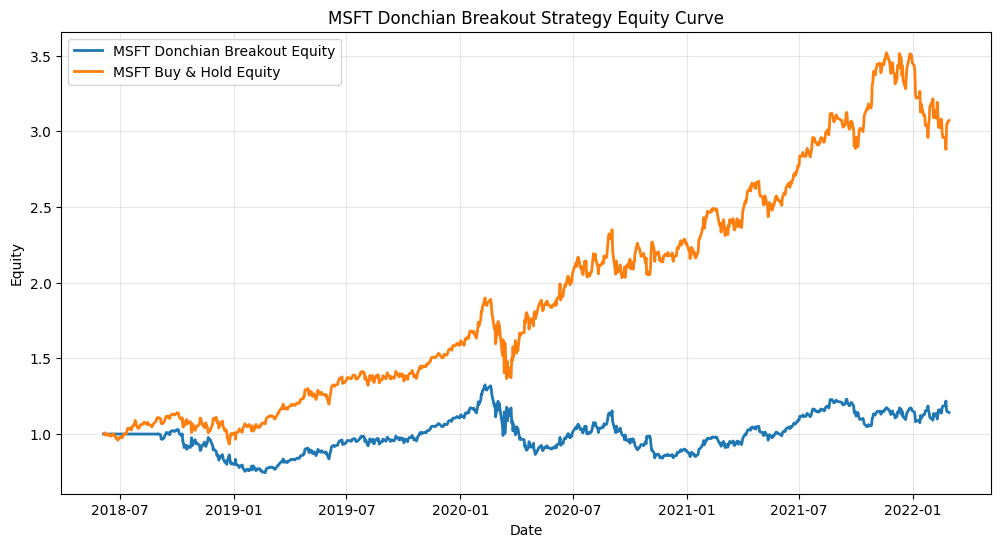


 Performance Metrics ---
Total Return              0.142451
Annualized Return         0.036269
Volatility                0.299875
Sharpe Ratio              0.118805
Max Drawdown             -0.364918
Total Trades Executed    23.000000
dtype: float64
 1.0    685
-1.0    196
 0.0     61
Name: count, dtype: int64
Date
2018-06-04    0.0
2018-06-05    0.0
2018-06-06    0.0
2018-06-07    0.0
2018-06-08    0.0
2018-06-11    0.0
2018-06-12    0.0
2018-06-13    0.0
2018-06-14    0.0
2018-06-15    0.0
2018-06-18    0.0
2018-06-19    0.0
2018-06-20    0.0
2018-06-21    0.0
2018-06-22    0.0
2018-06-25    0.0
2018-06-26    0.0
2018-06-27    0.0
2018-06-28    0.0
2018-06-29    0.0
2018-07-02    0.0
2018-07-03    0.0
2018-07-05    0.0
2018-07-06    0.0
2018-07-09    0.0
2018-07-10    0.0
2018-07-11    0.0
2018-07-12    0.0
2018-07-13    0.0
2018-07-16    0.0
dtype: float64
                close  position  position_shifted  log_return  strat_log
Date                                                  

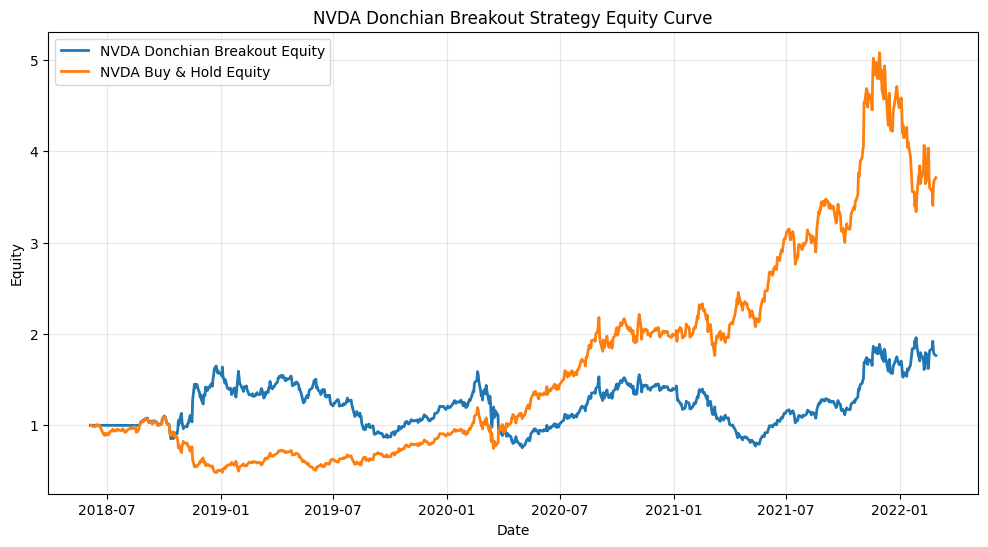


 Performance Metrics ---
Total Return              0.763759
Annualized Return         0.163929
Volatility                0.500065
Sharpe Ratio              0.303563
Max Drawdown             -0.542856
Total Trades Executed    27.000000
dtype: float64
 1.0    631
-1.0    255
 0.0     56
Name: count, dtype: int64
Date
2018-06-04    0.0
2018-06-05    0.0
2018-06-06    0.0
2018-06-07    0.0
2018-06-08    0.0
2018-06-11    0.0
2018-06-12    0.0
2018-06-13    0.0
2018-06-14    0.0
2018-06-15    0.0
2018-06-18    0.0
2018-06-19    0.0
2018-06-20    0.0
2018-06-21    0.0
2018-06-22    0.0
2018-06-25    0.0
2018-06-26    0.0
2018-06-27    0.0
2018-06-28    0.0
2018-06-29    0.0
2018-07-02    0.0
2018-07-03    0.0
2018-07-05    0.0
2018-07-06    0.0
2018-07-09    0.0
2018-07-10    0.0
2018-07-11    0.0
2018-07-12    0.0
2018-07-13    0.0
2018-07-16    0.0
dtype: float64
               close  position  position_shifted  log_return  strat_log
Date                                                   

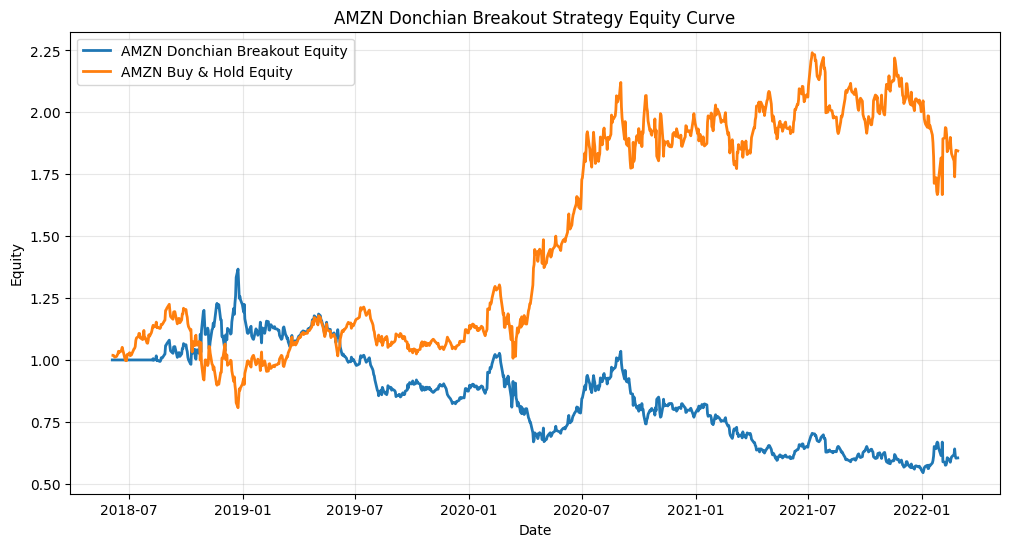


 Performance Metrics ---
Total Return             -0.395732
Annualized Return        -0.126073
Volatility                0.321425
Sharpe Ratio             -0.419251
Max Drawdown             -0.601619
Total Trades Executed    31.000000
dtype: float64
-1.0    458
 1.0    438
 0.0     46
Name: count, dtype: int64
Date
2018-06-04    0.0
2018-06-05    0.0
2018-06-06    0.0
2018-06-07    0.0
2018-06-08    0.0
2018-06-11    0.0
2018-06-12    0.0
2018-06-13    0.0
2018-06-14    0.0
2018-06-15    0.0
2018-06-18    0.0
2018-06-19    0.0
2018-06-20    0.0
2018-06-21    0.0
2018-06-22    0.0
2018-06-25    0.0
2018-06-26    0.0
2018-06-27    0.0
2018-06-28    0.0
2018-06-29    0.0
2018-07-02    0.0
2018-07-03    0.0
2018-07-05    0.0
2018-07-06    0.0
2018-07-09    0.0
2018-07-10    0.0
2018-07-11    0.0
2018-07-12    0.0
2018-07-13    0.0
2018-07-16    0.0
dtype: float64
                close  position  position_shifted  log_return  strat_log
Date                                                  

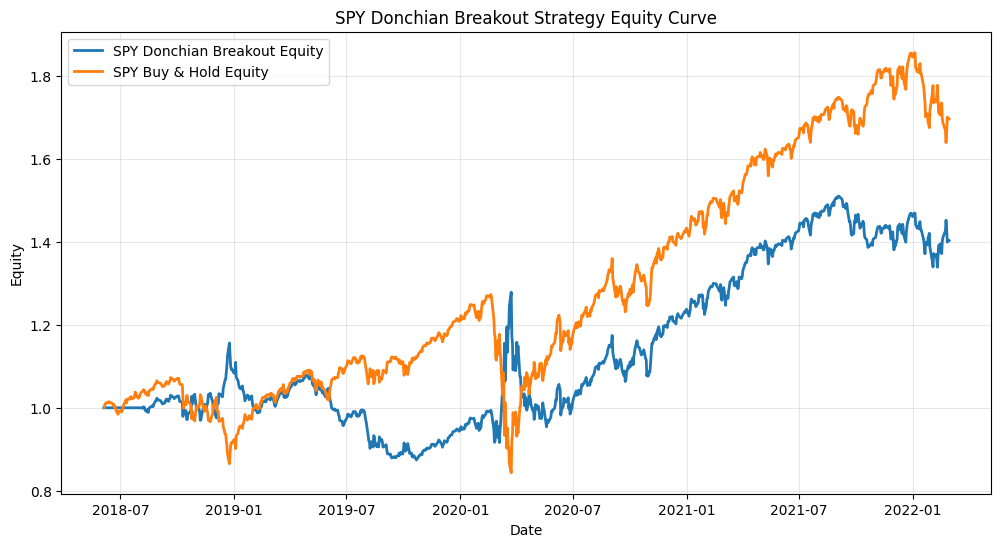


 Performance Metrics ---
Total Return              0.402696
Annualized Return         0.094750
Volatility                0.212231
Sharpe Ratio              0.426547
Max Drawdown             -0.253495
Total Trades Executed    23.000000
dtype: float64
 1.0    642
-1.0    256
 0.0     44
Name: count, dtype: int64
Date
2018-06-04    0.0
2018-06-05    0.0
2018-06-06    0.0
2018-06-07    0.0
2018-06-08    0.0
2018-06-11    0.0
2018-06-12    0.0
2018-06-13    0.0
2018-06-14    0.0
2018-06-15    0.0
2018-06-18    0.0
2018-06-19    0.0
2018-06-20    0.0
2018-06-21    0.0
2018-06-22    0.0
2018-06-25    0.0
2018-06-26    0.0
2018-06-27    0.0
2018-06-28    0.0
2018-06-29    0.0
2018-07-02    0.0
2018-07-03    0.0
2018-07-05    0.0
2018-07-06    0.0
2018-07-09    0.0
2018-07-10    0.0
2018-07-11    0.0
2018-07-12    0.0
2018-07-13    0.0
2018-07-16    0.0
dtype: float64
                 close  position  position_shifted  log_return  strat_log
Date                                                 

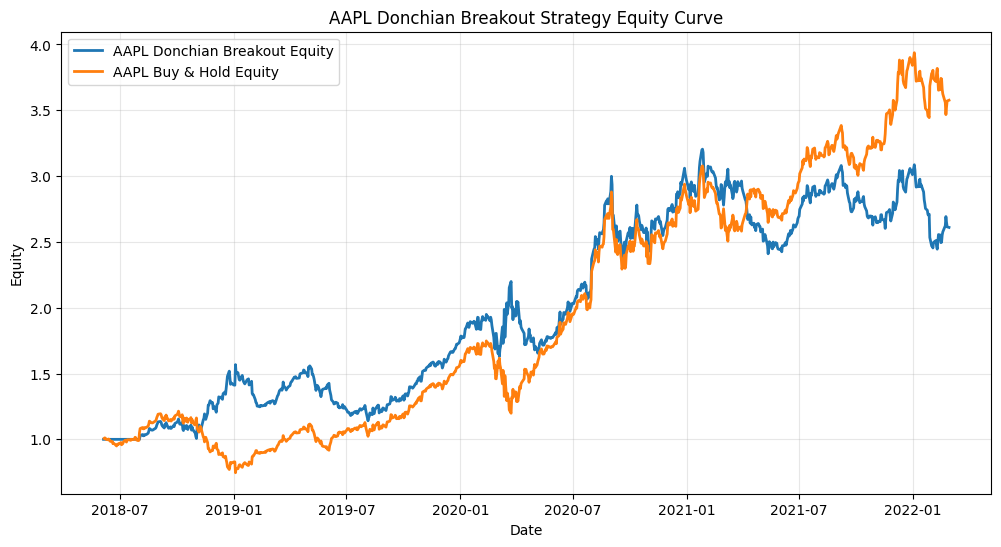


 Performance Metrics ---
Total Return              1.609880
Annualized Return         0.292566
Volatility                0.333037
Sharpe Ratio              0.770572
Max Drawdown             -0.271984
Total Trades Executed    23.000000
dtype: float64
 1.0    652
-1.0    249
 0.0     41
Name: count, dtype: int64
Date
2018-06-04    0.0
2018-06-05    0.0
2018-06-06    0.0
2018-06-07    0.0
2018-06-08    0.0
2018-06-11    0.0
2018-06-12    0.0
2018-06-13    0.0
2018-06-14    0.0
2018-06-15    0.0
2018-06-18    0.0
2018-06-19    0.0
2018-06-20    0.0
2018-06-21    0.0
2018-06-22    0.0
2018-06-25    0.0
2018-06-26    0.0
2018-06-27    0.0
2018-06-28    0.0
2018-06-29    0.0
2018-07-02    0.0
2018-07-03    0.0
2018-07-05    0.0
2018-07-06    0.0
2018-07-09    0.0
2018-07-10    0.0
2018-07-11    0.0
2018-07-12    0.0
2018-07-13    0.0
2018-07-16    0.0
dtype: float64
                close  position  position_shifted  log_return  strat_log
Date                                                  

In [8]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.ma_crossover import ma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("AAPL", "2023-06-01", "2026-03-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

print(type(close))
print(close.head())
# for lb in [10, 20, 40, 60]:
#     position = donchian_breakout_position(close, lookback=lb, threshold=0.0)
#     bt = backtest_log_returns(close, position, cost_per_trade=0.001)
#     print(f"lookback={lb}  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

position = donchian_breakout_position(close, lookback=40, threshold=0.0)
bt = backtest_log_returns(close, position, cost_per_trade=0.001)
print(f"Donchian Breakout Strategy (lookback=40)  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

position_long_only = position.clip(lower=0)  # Convert to long-only by setting short positions to 0
bt_long_only = backtest_log_returns(close, position_long_only, cost_per_trade=0.001)

for ticker in ["MSFT", "NVDA", "AMZN", "SPY", "AAPL"]:
    close = load_prices(ticker, "2018-06-01", "2022-03-01")["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    position = donchian_breakout_position(close, lookback=40, threshold=0.0)
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)
    print(f"{ticker} Donchian Breakout Strategy (lookback=40)  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

    buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

    plt.figure(figsize=(12, 6))
    plt.plot(bt["equity"], label=f"{ticker} Donchian Breakout Equity", linewidth=2)
    plt.plot(buy_hold_equity, label=f"{ticker} Buy & Hold Equity", linewidth=2)
    plt.title(f"{ticker} Donchian Breakout Strategy Equity Curve")
    plt.ylabel("Equity")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n Performance Metrics ---")
    print(evaluate_performance(bt))

    print(position.value_counts())
    print(position.head(30))
    print(bt[['close', 'position', 'position_shifted', 'log_return', 'strat_log']].head(30))
    print(bt['strat_log'].isna().sum(), "NaN strat_log values")
    print(bt['equity'].isna().sum(), "NaN equity values")


    